In [50]:
#!pip install nixtla

In [1]:

import pandas as pd
from nixtla import NixtlaClient
nixtla_client = NixtlaClient(api_key = 'nixak-fdeb395c1c38014d4292173c77382d77112264957706fd4bfd4ba3ea8d27da243ee0fa406f4a8105')
nixtla_client.validate_api_key()

INFO:nixtla.nixtla_client:Happy Forecasting! :)


True

In [2]:
## Load the data from file/files

In [2]:
#load data from cities

# 2. Read historic electricity demand data
df = pd.read_csv('netherland_hourly.csv')

df

,utc_timestamp,cet_cest_timestamp,NL_load_actual_entsoe_transparency,NL_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,9401.0,8937.0
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,8957.0,8608.0
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,8462.0,8462.0
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,8156.0,8500.0
...,...,...,...,...
43819,2019-12-31T18:00:00Z,2019-12-31T19:00:00+0100,13517.0,12380.0
43820,2019-12-31T19:00:00Z,2019-12-31T20:00:00+0100,12799.0,11820.0
43821,2019-12-31T20:00:00Z,2019-12-31T21:00:00+0100,12065.0,11163.0
43822,2019-12-31T21:00:00Z,2019-12-31T22:00:00+0100,11641.0,10605.0


## Select training data based on Scenario

In [3]:
# Select data for training # 
fra = '2018-01-01'
til = '2018-11-01'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
trainData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
trainData

,utc_timestamp,cet_cest_timestamp,NL_load_actual_entsoe_transparency,NL_load_forecast_entsoe_transparency
26305,2018-01-01T00:00:00Z,2018-01-01T01:00:00+0100,10690.0,11048.0
26306,2018-01-01T01:00:00Z,2018-01-01T02:00:00+0100,10354.0,10711.0
26307,2018-01-01T02:00:00Z,2018-01-01T03:00:00+0100,10032.0,10577.0
26308,2018-01-01T03:00:00Z,2018-01-01T04:00:00+0100,9766.0,10654.0
26309,2018-01-01T04:00:00Z,2018-01-01T05:00:00+0100,9768.0,11085.0
...,...,...,...,...
33596,2018-10-31T19:00:00Z,2018-10-31T20:00:00+0100,15350.0,15778.0
33597,2018-10-31T20:00:00Z,2018-10-31T21:00:00+0100,14275.0,14949.0
33598,2018-10-31T21:00:00Z,2018-10-31T22:00:00+0100,13134.0,13894.0
33599,2018-10-31T22:00:00Z,2018-10-31T23:00:00+0100,12158.0,12997.0


In [4]:
len(trainData)

7296

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


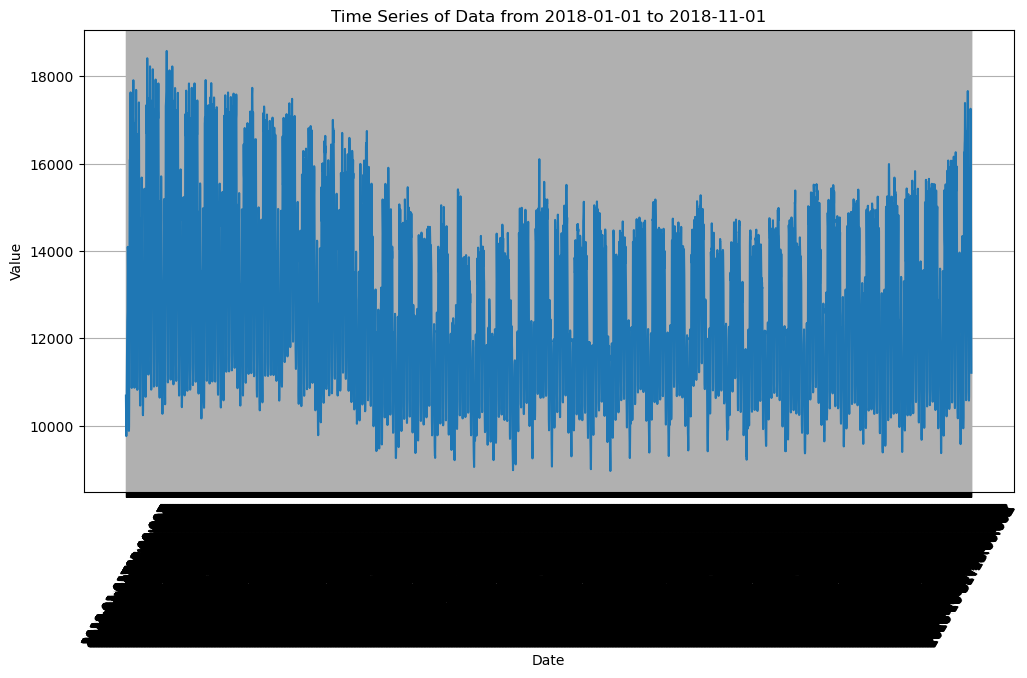

In [5]:
# Basic time series plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(trainData['utc_timestamp'], trainData['NL_load_actual_entsoe_transparency'])
plt.title(f'Time Series of Data from {fra} to {til}')
plt.xlabel('Date')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Value')
plt.grid(True)
plt.show()

## Validation data selection based on scenario

In [6]:
# Select data for validation # 
fra = '2018-11-01'
til = '2018-12-01'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
validData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
validData = validData.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'actual'})
validData

,ds,cet_cest_timestamp,actual,NL_load_forecast_entsoe_transparency
33601,2018-11-01T00:00:00Z,2018-11-01T01:00:00+0100,10722.0,11382.0
33602,2018-11-01T01:00:00Z,2018-11-01T02:00:00+0100,10563.0,11072.0
33603,2018-11-01T02:00:00Z,2018-11-01T03:00:00+0100,10540.0,10977.0
33604,2018-11-01T03:00:00Z,2018-11-01T04:00:00+0100,10584.0,11034.0
33605,2018-11-01T04:00:00Z,2018-11-01T05:00:00+0100,11084.0,11475.0
...,...,...,...,...
34316,2018-11-30T19:00:00Z,2018-11-30T20:00:00+0100,15119.0,15692.0
34317,2018-11-30T20:00:00Z,2018-11-30T21:00:00+0100,14163.0,14656.0
34318,2018-11-30T21:00:00Z,2018-11-30T22:00:00+0100,13154.0,13595.0
34319,2018-11-30T22:00:00Z,2018-11-30T23:00:00+0100,12444.0,12779.0


In [7]:
len(validData)

720

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


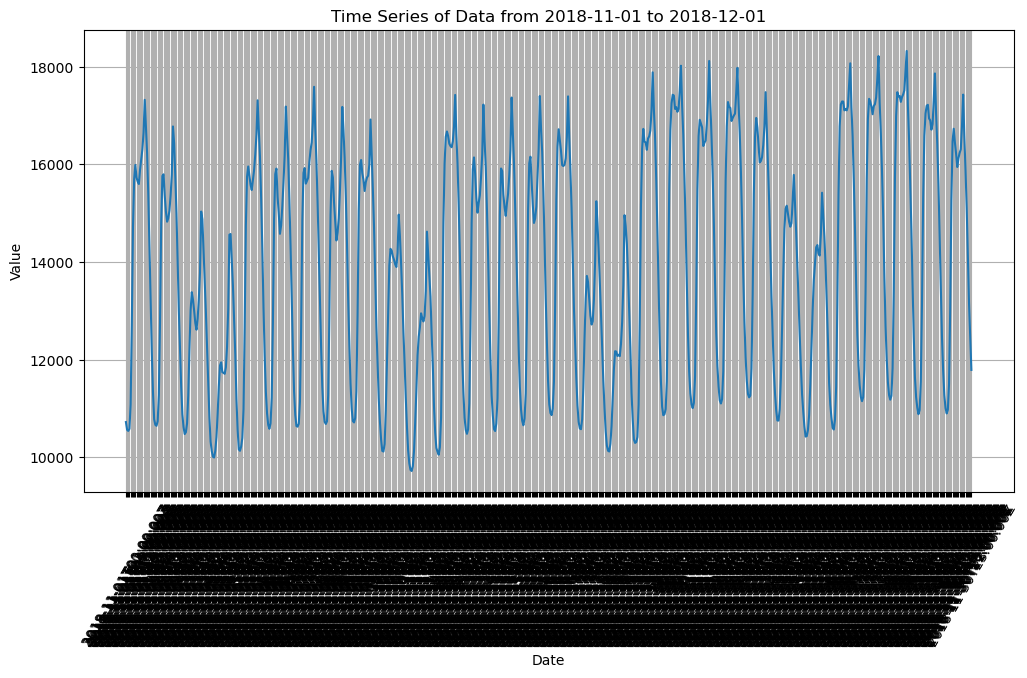

In [8]:
# Basic time series plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(validData['ds'], validData['actual'])
plt.title(f'Time Series of Data from {fra} to {til}')
plt.xlabel('Date')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
   
plt.ylabel('Value')
plt.grid(True)
plt.show()


## Forcasting wsith timeGPT

In [9]:
# 3. Forecast the next 24 hours
# First, ensure your DataFrame has the required column names
# Nixtla typically expects 'ds' for the timestamp column and 'y' for the target variable

# Assuming trainData has a datetime column with a different name (e.g., 'date' or 'timestamp')
# Rename it to match Nixtla's expected format
trainData = trainData.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'y'})

# Now try forecasting again
fcst_df = nixtla_client.forecast(trainData, 
                                 h=len(validData), 
                                 freq='H',
                                 model='timegpt-1-long-horizon')

INFO:nixtla.nixtla_client:Validating inputs...
/opt/anaconda3/lib/python3.13/site-packages/utilsforecast/preprocessing.py:123: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
/opt/anaconda3/lib/python3.13/site-packages/utilsforecast/processing.py:378: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/opt/anaconda3/lib/python3.13/site-packages/utilsforecast/processing.py:434: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


In [10]:
fcst_df

,ds,TimeGPT
0,2018-11-01 00:00:00+00:00,10732.887
1,2018-11-01 01:00:00+00:00,10746.141
2,2018-11-01 02:00:00+00:00,10567.215
3,2018-11-01 03:00:00+00:00,10815.703
4,2018-11-01 04:00:00+00:00,11849.785
...,...,...
715,2018-11-30 19:00:00+00:00,14231.961
716,2018-11-30 20:00:00+00:00,13178.754
717,2018-11-30 21:00:00+00:00,12189.868
718,2018-11-30 22:00:00+00:00,11342.118


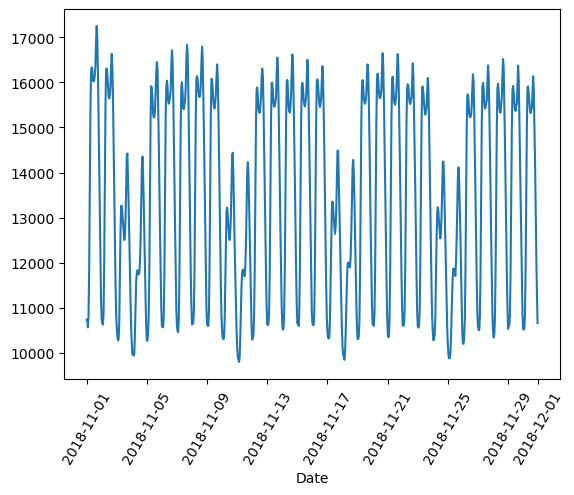

In [11]:
# Membuat plot
plt.plot(fcst_df['ds'], fcst_df['TimeGPT'])
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])
#plt.plot(trainData['utc_timestamp'], trainData['PL_load_actual_entsoe_transparency'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Date')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees


# Menampilkan plot
plt.show()

## Merge forecast n actual

In [12]:
# Convert the 'ds' column in both DataFrames to the same data type (datetime)
fcst_df['ds'] = pd.to_datetime(fcst_df['ds'])
validData['ds'] = pd.to_datetime(validData['ds'])

# Now merge the DataFrames
result = pd.merge(fcst_df, validData, on='ds', how='inner')

In [13]:
result

,ds,TimeGPT,cet_cest_timestamp,actual,NL_load_forecast_entsoe_transparency
0,2018-11-01 00:00:00+00:00,10732.887,2018-11-01T01:00:00+0100,10722.0,11382.0
1,2018-11-01 01:00:00+00:00,10746.141,2018-11-01T02:00:00+0100,10563.0,11072.0
2,2018-11-01 02:00:00+00:00,10567.215,2018-11-01T03:00:00+0100,10540.0,10977.0
3,2018-11-01 03:00:00+00:00,10815.703,2018-11-01T04:00:00+0100,10584.0,11034.0
4,2018-11-01 04:00:00+00:00,11849.785,2018-11-01T05:00:00+0100,11084.0,11475.0
...,...,...,...,...,...
715,2018-11-30 19:00:00+00:00,14231.961,2018-11-30T20:00:00+0100,15119.0,15692.0
716,2018-11-30 20:00:00+00:00,13178.754,2018-11-30T21:00:00+0100,14163.0,14656.0
717,2018-11-30 21:00:00+00:00,12189.868,2018-11-30T22:00:00+0100,13154.0,13595.0
718,2018-11-30 22:00:00+00:00,11342.118,2018-11-30T23:00:00+0100,12444.0,12779.0


## Metrics calculation (rRMSE and rMAE)

In [14]:
import numpy as np
# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(result['actual'])

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(result['actual'] - result['TimeGPT']))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((result['actual'] - result['TimeGPT'])**2))
rrmse = rmse / y_mean

metricResult = f'rRMSE: {rrmse:.4f} rMAE: {rmae:.4f} '
print(metricResult)



rRMSE: 0.0560 rMAE: 0.0433 


## Comparison of GPT vs Actual

In [17]:
city = 'Hourly the netherland TimeGPT'

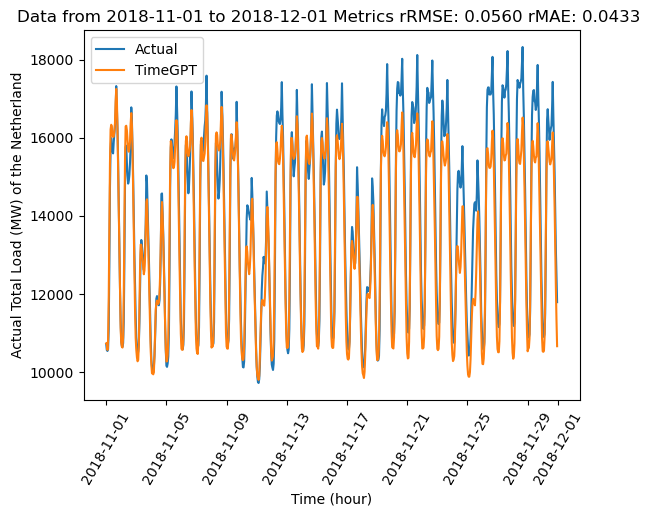

In [18]:
# plot Result dan save

plt.plot(result['ds'], result['actual'], label='Actual')
plt.plot(result['ds'], result['TimeGPT'],label='TimeGPT')
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Time (hour)')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Actual Total Load (MW) of the Netherland')
#plt.title('Plot of Combined Value over Date')
plt.title(f'Data from {fra} to {til} Metrics {metricResult}')


# Menambahkan legenda
plt.legend()

# Mengganti spasi dan karakter khusus dengan garis bawah
#result_cleaned = result.replace(' ', '_').replace(':', '_')

# Menyimpan plot ke file gambar dengan judul yang diperbarui
#plt.savefig(f'./time_gpt/result_pure_time_gpt_{result_cleaned}.png')
plt.savefig(f'Plot {city} from {fra} to {til} metric {metricResult}.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()
